In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from helpers import load_model_class
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob
from matplotlib.colors import ListedColormap

from rasterio.windows import Window
# Add src to path
sys.path.insert(0, '/home/user/src')
import rasterio as rio
from datasets import BuildingCoverageRaster, PASTIS, BuildingBinaryRaster, BurnScars

from settings import *

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
import glob
from models.models_finetune import DownstreamModel
from models.LIANet import LIANetLight
import omegaconf, hydra

pretrained_model_path = {"BFPDensity_joint_T31TFM": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "BFPDensity_joint_T32ULU": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "BFPDensity_local_T31TFM": "/home/user/results_shared/fourier_learned_T31TFM/2026-04-08_00-13-56",
                         "BFPDensity_local_T32ULU": "/home/user/results_shared/fourier_learned_T32ULU/2026-04-04_09-21-54",
                         "PASTIS_joint_T31TFM": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "PASTIS_joint_T32ULU": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "PASTIS_joint_T31TFJ": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "PASTIS_joint_T30UXV": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "PASTIS_local_T31TFM": "/home/user/results_shared/fourier_learned_T31TFM/2026-04-08_00-13-56",
                         "PASTIS_local_T32ULU": "/home/user/results_shared/fourier_learned_T32ULU/2026-04-04_09-21-54",
                         "PASTIS_local_T31TFJ": "/home/user/results_shared/fourier_learned_T31TFJ/2026-04-02_13-40-05",
                         "PASTIS_local_T30UXV": "/home/user/results_shared/fourier_learned_T30UXV/2026-04-06_04-50-55",
                         "BFPBinary_joint_T31TFM": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "BFPBinary_joint_T32ULU": "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01",
                         "BFPBinary_local_T31TFM": "/home/user/results_shared/fourier_learned_T31TFM/2026-04-08_00-13-56",
                         "BFPBinary_local_T32ULU": "/home/user/results_shared/fourier_learned_T32ULU/2026-04-04_09-21-54",
                         "BurnScars_joint_T11SMT": "/home/user/results_shared/fourier_learned_HLS_2regions/2026-04-22_15-34-35",
                         "BurnScars_joint_T16REV": "/home/user/results_shared/fourier_learned_HLS_2regions/2026-04-22_15-34-35",
                         "BurnScars_local_T11SMT": "/home/user/results_shared/fourier_learned_HLS_T11SMT/2026-04-30_20-30-35",
                         "BurnScars_local_T16REV": "/home/user/results_shared/fourier_learned_HLS_T16REV/2026-04-28_09-13-10"}


def load_model(CKPT_PATH, other_task, model_type):
    model_finetune = load_model_class(
        other_task, 
        model_type, 
        MODEL_PATH= pretrained_model_path[other_task],
        NUM_CLASSES=num_classes[other_task],
        ACTIVATION_FUNCTION=activation_functions[other_task]
    )
    checkpoint = torch.load(CKPT_PATH, map_location=device)
    state_dict = checkpoint["model_state_dict"]
    if state_dict and all(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k[len("module."):]: v for k, v in state_dict.items()}

    model_finetune.load_state_dict(state_dict, strict=True)

    model_finetune = model_finetune.to(device)
    model_finetune.eval()
    # print("✓ Model loaded successfully")
    return model_finetune

In [ ]:
import os
import torch
import pandas as pd
from utils import s2_to_rgb
from tqdm import tqdm
from torchmetrics import MetricCollection
from metrics import regression_metrics

model_type_list = ["replace_final_block"]

for model_type in model_type_list:

    # all_tasks_list = {
    #     "BFPDensity_joint_T31TFM": ["BFPDensity_joint_T32ULU"],
    #     "BFPDensity_local_T31TFM": ["BFPDensity_local_T31TFM"],
    # }
    Target_region = "BFPDensity_joint_T31TFM"

    BATCH_SIZE = 16
    NUM_WORKERS = 8
    

    application_name = Target_region.split("_")[0]
    # other_tasks = all_tasks_list[Target_region]
    
    # Dataset of the Target region for evaluation
    val_dataset = BuildingCoverageRaster(
        top_dir=TOP_DIR[Target_region],
        s2_tiles=s2_tiles[Target_region],
        labels=labels[Target_region],
        train_val_key="val",
    )

    dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False,
    )

    startername = "LIANet"
    model_dir_joint = glob.glob(f"/home/user/results_local/finetuning_results_BFPDensity/BFPDensity_joint_T32ULU/{startername}*")
    run_name_joint = sorted(os.listdir(model_dir_joint[0]))[:1]
    ckpt_path_joint = os.path.join(model_dir_joint[0], run_name_joint[0], "last.pt")

    model_joint = load_model(ckpt_path_joint, Target_region, model_type)
    model_joint.eval()

    model_dir_local = glob.glob(f"/home/user/results_local/finetuning_results_BFPDensity/BFPDensity_local_T31TFM/{startername}*")
    run_name_local = sorted(os.listdir(model_dir_local[0]))[:1]   
    ckpt_path_local = os.path.join(model_dir_local[0], run_name_local[0], "last.pt")
    model_local = load_model(ckpt_path_local, "BFPDensity_local_T31TFM", model_type)
    model_local.eval()

    with torch.no_grad():
        for idx, batch in enumerate(
            tqdm(dataloader, leave=False)):
            x = batch["x_s2"].to(device)
            y = batch["y_s2"].to(device)
            label = batch["label"]
            delta_days = batch["delta_days"].to(device)
            target_tile = Target_region.split("_")[-1]
            s2data  = batch["s2data"].to(device)

            reconstr_joint, pred_joint = model_joint(
                delta_days,
                x,
                y,
                torch.tensor([2], device=device),
            )
            reconstr_local, pred_local = model_local(
                delta_days,
                x,
                y,
                torch.tensor([0], device=device),
            )
            fig, ax =plt.subplots(1,6, figsize=(11, 2.2), dpi=600)
            ax[0].imshow(s2_to_rgb(s2data[0].cpu()))
            # ax[0].set_title("S2 Image")

            ax[1].imshow(s2_to_rgb(reconstr_joint[0].cpu()).astype(np.float32))
            # ax[1].set_title("Joint Reconstr.")

            ax[2].imshow(s2_to_rgb(reconstr_local[0].cpu()).astype(np.float32))
            # ax[2].set_title("Local Reconstr.")

            ax[3].imshow(label[0].detach().cpu().numpy().astype(np.float32))
            # ax[3].set_title("GT Label")

            ax[4].imshow(
                pred_joint[0].detach().cpu().numpy().astype(np.float32).squeeze(),
                vmin=0, vmax=1
            )
            # ax[4].set_title("Joint Pred.")

            ax[5].imshow(
                pred_local[0].detach().cpu().numpy().astype(np.float32).squeeze(),
                vmin=0, vmax=1
            )
            # ax[5].set_title("Local Pred.")

            
            for a in ax:
                a.axis("off")
            plt.tight_layout()
            plt.savefig(f"Figs/BFPDensity/BFPDensity_comparison_{idx}.png", dpi=600, bbox_inches="tight")





In [ ]:
import os
import torch
import pandas as pd
from helpers import provide_cmap
from utils import s2_to_rgb
from tqdm import tqdm
from torchmetrics import MetricCollection
from metrics import regression_metrics

model_type_list = ["replace_final_block"]
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 9
})

colors = [
    (0, 0, 0),
    (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
    (1.0, 0.4980392156862745, 0.054901960784313725),
    (1.0, 0.7333333333333333, 0.47058823529411764),
    (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
    (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
    (1.0, 0.596078431372549, 0.5882352941176471),
    (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
    (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
    (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
    (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
    (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
    (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
    (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
    (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
    (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
    (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
    (1, 1, 1),
]
vvmin, vvmax = 0, 19
for model_type in model_type_list:

    # all_tasks_list = {
    #     "BFPDensity_joint_T31TFM": ["BFPDensity_joint_T32ULU"],
    #     "BFPDensity_local_T31TFM": ["BFPDensity_local_T31TFM"],
    # }
    Target_region = "PASTIS_joint_T31TFM"

    BATCH_SIZE = 16
    NUM_WORKERS = 8
    

    application_name = Target_region.split("_")[0]
    # other_tasks = all_tasks_list[Target_region]
    
    # Dataset of the Target region for evaluation
    val_dataset = PASTIS(
        top_dir=TOP_DIR[Target_region],
        s2_tiles=s2_tiles[Target_region],
        labels=labels[Target_region],
        val_folds=[3],
        train_val_key="val",
    )

    dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False,
    )

    startername = "LIANet"
    model_dir_joint = glob.glob(f"/home/user/results_local/finetuning_results_PASTIS/PASTIS_joint_T32ULU/{startername}*")
    run_name_joint = sorted(os.listdir(model_dir_joint[0]))[:1]
    ckpt_path_joint = os.path.join(model_dir_joint[0], run_name_joint[0], "last.pt")

    model_joint = load_model(ckpt_path_joint, Target_region, model_type)
    model_joint.eval()

    model_dir_local = glob.glob(f"/home/user/results_local/finetuning_results_PASTIS/PASTIS_local_T31TFM/{startername}*")
    run_name_local = sorted(os.listdir(model_dir_local[0]))[:1]   
    ckpt_path_local = os.path.join(model_dir_local[0], run_name_local[0], "last.pt")
    model_local = load_model(ckpt_path_local, "PASTIS_local_T31TFM", model_type)
    model_local.eval()

    with torch.no_grad():
        for idx, batch in enumerate(
            tqdm(dataloader, leave=False)):
            x = batch["x_s2"].to(device)
            y = batch["y_s2"].to(device)
            label = batch["label"]
            delta_days = batch["delta_days"].to(device)
            target_tile = Target_region.split("_")[-1]
            s2data  = batch["s2data"].to(device)

            reconstr_joint, pred_joint = model_joint(
                delta_days,
                x,
                y,
                torch.tensor([2], device=device),
            )
            reconstr_local, pred_local = model_local(
                delta_days,
                x,
                y,
                torch.tensor([0], device=device),
            )
            fig, ax =plt.subplots(1,6, figsize=(11, 2.2), dpi=600)
            ax[0].imshow(s2_to_rgb(s2data[0].cpu()))
            ax[0].set_title("S2 Image")

            ax[1].imshow(s2_to_rgb(reconstr_joint[0].cpu()).astype(np.float32))
            ax[1].set_title("Joint Reconstr.")

            ax[2].imshow(s2_to_rgb(reconstr_local[0].cpu()).astype(np.float32))
            ax[2].set_title("Local Reconstr.")
            cmap = ListedColormap(colors)
            ax[3].imshow(label[0].detach().cpu().numpy().astype(np.float32), cmap=cmap, vmin=vvmin, vmax=vvmax)
            ax[3].set_title("GT Label")

            ax[4].imshow(
                torch.argmax(pred_joint[0], axis=0).detach().cpu().numpy().astype(np.float32).squeeze(),
                cmap=cmap, vmin=vvmin, vmax=vvmax
            )
            ax[4].set_title("Joint Pred.")

            ax[5].imshow(
                torch.argmax(pred_local[0], axis=0).detach().cpu().numpy().astype(np.float32).squeeze(),
                cmap=cmap, vmin=vvmin, vmax=vvmax
            )
            ax[5].set_title("Local Pred.")

            
            for a in ax:
                a.axis("off")
            plt.tight_layout()
            plt.savefig(f"Figs/PASTIS/PASTIS_comparison_{idx}.png", dpi=600, bbox_inches="tight")
            # plt.show()
            if idx > 100:
                break
        





In [ ]:
so =  torch.argmax(pred_local[0], axis=0).detach().cpu().numpy().astype(np.float32).squeeze()

In [ ]:
import os
import torch
import pandas as pd
from helpers import provide_cmap
from utils import s2_to_rgb
from tqdm import tqdm
from torchmetrics import MetricCollection
from metrics import regression_metrics

model_type_list = ["replace_final_block"]

for model_type in model_type_list:

    # all_tasks_list = {
    #     "BFPDensity_joint_T31TFM": ["BFPDensity_joint_T32ULU"],
    #     "BFPDensity_local_T31TFM": ["BFPDensity_local_T31TFM"],
    # }
    Target_region = "BurnScars_joint_T16REV"

    BATCH_SIZE = 16
    NUM_WORKERS = 8
    

    application_name = Target_region.split("_")[0]
    # other_tasks = all_tasks_list[Target_region]
    
    # Dataset of the Target region for evaluation
    val_dataset = BurnScars(
        top_dir=TOP_DIR[Target_region],
        s2_tiles=s2_tiles[Target_region],
        labels=labels[Target_region],
        train_val_key="val",
    )

    dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False,
    )

    startername = "LIANet"
    model_dir_joint = glob.glob(f"/home/user/results_local/finetuning_results_BurnScars/BurnScars_joint_T11SMT/{startername}*")
    run_name_joint = sorted(os.listdir(model_dir_joint[0]))[:1]
    ckpt_path_joint = os.path.join(model_dir_joint[0], run_name_joint[0], "last.pt")

    model_joint = load_model(ckpt_path_joint, Target_region, model_type)
    model_joint.eval()

    model_dir_local = glob.glob(f"/home/user/results_local/finetuning_results_BurnScars/BurnScars_local_T16REV/{startername}*")
    run_name_local = sorted(os.listdir(model_dir_local[0]))[:1]   
    ckpt_path_local = os.path.join(model_dir_local[0], run_name_local[0], "last.pt")
    model_local = load_model(ckpt_path_local, "BurnScars_local_T16REV", model_type)
    model_local.eval()

    with torch.no_grad():
        for idx, batch in enumerate(
            tqdm(dataloader, leave=False)):
            x = batch["x_s2"].to(device)
            y = batch["y_s2"].to(device)
            label = batch["label"]
            delta_days = batch["delta_days"].to(device)
            target_tile = Target_region.split("_")[-1]
            s2data  = batch["s2data"].to(device)

            reconstr_joint, pred_joint = model_joint(
                delta_days,
                x,
                y,
                torch.tensor([1], device=device),
            )
            reconstr_local, pred_local = model_local(
                delta_days,
                x,
                y,
                torch.tensor([0], device=device),
            )
            for i in range(len(batch["x_s2"])):
                fig, ax =plt.subplots(1,6, figsize=(11, 2.2), dpi=600)
                ax[0].imshow(s2_to_rgb(s2data[i].cpu()))
                # ax[0].set_title("S2 Image")

                ax[1].imshow(s2_to_rgb(reconstr_joint[i].cpu()).astype(np.float32))
                # ax[1].set_title("Joint Reconstr.")

                ax[2].imshow(s2_to_rgb(reconstr_local[i].cpu()).astype(np.float32))
                # ax[2].set_title("Local Reconstr.")
                ax[3].imshow(label[i].detach().cpu().numpy().astype(np.float32), vmin=0, vmax=1, cmap="gray",)
                # ax[3].set_title("GT Label")

                ax[4].imshow(
                    torch.argmax(pred_joint[i], axis=0).detach().cpu().numpy().astype(np.float32).squeeze(), cmap="gray",
                    vmin=0, vmax=1
                )
                # ax[4].set_title("Joint Pred.")

                ax[5].imshow(
                    torch.argmax(pred_local[i], axis=0).detach().cpu().numpy().astype(np.float32).squeeze(), cmap="gray",
                    vmin=0, vmax=1
                )
                # ax[5].set_title("Local Pred.")

                
                for a in ax:
                    a.axis("off")
                plt.tight_layout()
                plt.savefig(f"Figs/BurnScars/BurnScars_comparison_{idx}_{i}.png", dpi=600, bbox_inches="tight")
                # plt.show()





In [ ]:
import os
import torch
import pandas as pd
from utils import s2_to_rgb
from tqdm import tqdm
from torchmetrics import MetricCollection
from metrics import regression_metrics

model_type_list = ["replace_final_block_4x"]

for model_type in model_type_list:

    # all_tasks_list = {
    #     "BFPDensity_joint_T31TFM": ["BFPDensity_joint_T32ULU"],
    #     "BFPDensity_local_T31TFM": ["BFPDensity_local_T31TFM"],
    # }
    Target_region = "BFPBinary_joint_T31TFM"

    BATCH_SIZE = 16
    NUM_WORKERS = 8
    

    application_name = Target_region.split("_")[0]
    # other_tasks = all_tasks_list[Target_region]
    
    # Dataset of the Target region for evaluation
    val_dataset = BuildingCoverageRaster(
        top_dir=TOP_DIR[Target_region],
        s2_tiles=s2_tiles[Target_region],
        labels=labels[Target_region],
        train_val_key="val",
    )

    dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False,
    )

    startername = "replace_final_block_4x"
    model_dir_joint = glob.glob(f"/home/user/results_local/finetuning_results_BFPBinary/BFPBinary_joint_T32ULU/{startername}*")
    run_name_joint = sorted(os.listdir(model_dir_joint[0]))[:1]
    ckpt_path_joint = os.path.join(model_dir_joint[0], run_name_joint[0], "last.pt")

    model_joint = load_model(ckpt_path_joint, Target_region, model_type)
    model_joint.eval()

    model_dir_local = glob.glob(f"/home/user/results_local/finetuning_results_BFPBinary/BFPBinary_local_T31TFM/{startername}*")
    run_name_local = sorted(os.listdir(model_dir_local[0]))[:1]   
    ckpt_path_local = os.path.join(model_dir_local[0], run_name_local[0], "last.pt")
    model_local = load_model(ckpt_path_local, "BFPBinary_local_T31TFM", model_type)
    model_local.eval()

    with torch.no_grad():
        for idx, batch in enumerate(
            tqdm(dataloader, leave=False)):
            x = batch["x_s2"].to(device)
            y = batch["y_s2"].to(device)
            label = batch["label"]
            delta_days = batch["delta_days"].to(device)
            target_tile = Target_region.split("_")[-1]
            s2data  = batch["s2data"].to(device)

            reconstr_joint, pred_joint = model_joint(
                delta_days,
                x,
                y,
                torch.tensor([2], device=device),
            )
            reconstr_local, pred_local = model_local(
                delta_days,
                x,
                y,
                torch.tensor([0], device=device),
            )
            fig, ax =plt.subplots(1,6, figsize=(11, 2.2), dpi=600)
            ax[0].imshow(s2_to_rgb(s2data[0].cpu()))
            # ax[0].set_title("S2 Image")

            ax[1].imshow(s2_to_rgb(reconstr_joint[0].cpu()).astype(np.float32))
            # ax[1].set_title("Joint Reconstr.")

            ax[2].imshow(s2_to_rgb(reconstr_local[0].cpu()).astype(np.float32))
            # ax[2].set_title("Local Reconstr.")

            ax[3].imshow(label[0].detach().cpu().numpy().astype(np.float32), cmap="gray", vmin=0, vmax=1)
            # ax[3].set_title("GT Label")

            ax[4].imshow(
                torch.argmax(pred_joint[0], axis=0).detach().cpu().numpy().astype(np.float32).squeeze(), cmap="gray",
                vmin=0, vmax=1
            )
            # ax[4].set_title("Joint Pred.")

            ax[5].imshow(
                torch.argmax(pred_local[0], axis=0).detach().cpu().numpy().astype(np.float32).squeeze(), cmap="gray",
                vmin=0, vmax=1
            )
            # ax[5].set_title("Local Pred.")

            
            for a in ax:
                a.axis("off")
            plt.tight_layout()
            plt.savefig(f"Figs/BFPBinary/BFPBinary_comparison_{idx}.png", dpi=600, bbox_inches="tight")





In [ ]:
model_dir_joint

/tmp/ipykernel_821420/176565850.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


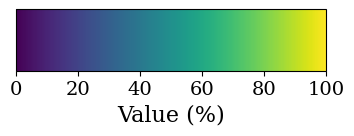

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Use serif font
plt.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(4, 0.8))

# Data range: 0 to 1
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = plt.cm.viridis

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap,
    norm=norm,
    orientation='horizontal'
)

# Tick positions
ticks = np.linspace(0, 1, 6)
cb.set_ticks(ticks)

# Label as percentages
cb.set_ticklabels([f"{int(t*100)}" for t in ticks])

cb.set_label("Value (%)", fontsize=16)
cb.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()